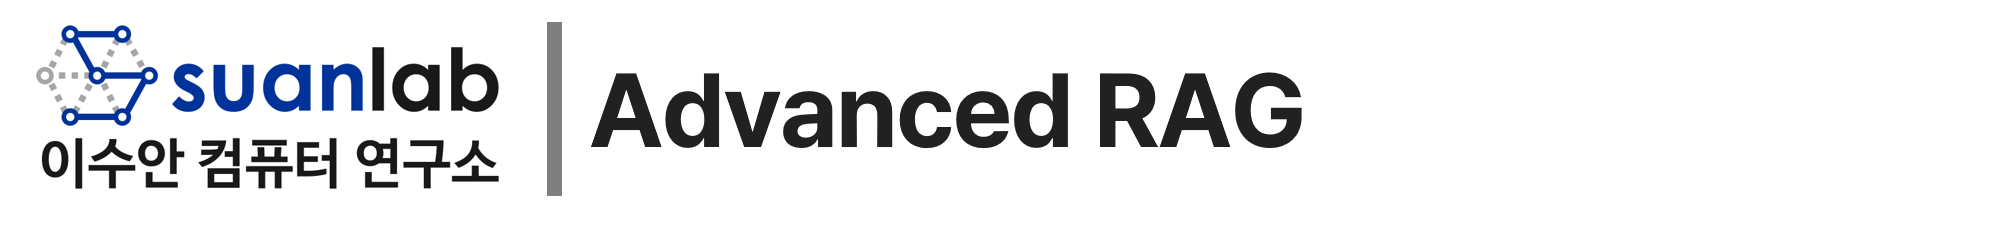

# 🗂️ 메타데이터·테이블 & Contextual Retrieval

## 환경 셋업 (맨 처음 한 번만 실행)

In [1]:
# === 환경 셋업 — 이 통합 노트북에서 "한 번만" 실행하면 전체 파트에서 그대로 씁니다 ===
# 비-Claude 라이브러리는 검색·그래프 인프라용입니다(Claude는 임베딩·BM25·리랭크·그래프 미제공).
!pip install -q "anthropic>=0.40" chromadb sentence-transformers

import os, getpass, json, re, math, random, collections, textwrap
if not os.environ.get("ANTHROPIC_API_KEY"):
    os.environ["ANTHROPIC_API_KEY"] = getpass.getpass("Anthropic API Key: ")
from anthropic import Anthropic
client = Anthropic()
MODEL = "claude-sonnet-4-6"   # 정확도가 중요한 judge·추출 단계는 "claude-opus-4-8"로 상향 가능
print("환경 셋업 완료 — API 키 입력됨, client·MODEL 준비됨")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 923.9/923.9 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 85.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not current

In [2]:
# 한글 폰트 설정 (Colab 환경)
!apt-get install -y fonts-nanum > /dev/null 2>&1
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
print("한글 폰트 설정 완료!")

한글 폰트 설정 완료!


# 메타데이터 필터 & 테이블 직렬화

## 학습목표
- 메타데이터(year/doc_type/company) **필터**로 검색 정밀도를 높임
- **Self-Query**: Claude가 자연어 질문에서 메타 필터를 추출하게 함
- 합성 **재무표**를 행 직렬화 + Claude 요약 후 색인해 표를 검색 가능하게 함

## 사전개념
- 메타필터: 의미 검색 전에 후보를 좁힘(연도·문서종류·회사)
- Self-Query: "2023년 노바테크 매출" → `{company:"노바테크", year:2023}` 자동 추출
- 표 임베딩 한계: 표는 그대로 임베딩하면 의미가 흐려져 → 직렬화/요약이 필요

> 비-Claude: chromadb(메타필터 내장 벡터DB), sentence-transformers(임베딩)

## 용어 미니 사전 (메타데이터·표 편)
검색을 더 똑똑하게: **"무엇을" 찾기 전에 "어느 범위에서" 찾을지 좁힘**

| 용어 | 한 줄 뜻 |
|---|---|
| **메타데이터(metadata)** | 문서에 붙은 꼬리표(회사·연도·문서종류 등) |
| **메타필터(filter)** | 검색 전에 꼬리표로 후보를 좁히는 것 (예: 2023년·재무만) |
| **Self-Query** | 사람이 필터를 손으로 안 짜도, Claude가 질문에서 필터를 자동으로 뽑아주는 것 |
| **precision@k(정밀도)** | 검색된 상위 k개 중 *정답 영역인 것의 비율* |
| **직렬화(serialize)** | 표의 한 줄을 "회사=노바테크, 연도=2023, ..." 같은 문장으로 펴는 것 |
| **Text2SQL** | 자연어 질문을 데이터베이스 조회문(SQL)으로 바꾸는 것 |
| **벡터DB(chromadb)** | 임베딩과 메타데이터를 함께 저장하고 필터 검색을 지원하는 저장소 |

> 핵심 메시지: 의미가 비슷한 엉뚱한 연도/회사 문서를 **꼬리표 필터로 먼저 걸러내면** 검색 정밀도가 오름  
표는 SQL로 묻는 게 더 정확함


## 메타데이터 부여 문서
- 각 문서에 company/year/doc_type 메타를 단다(가상)

### 꼬리표(메타데이터) 달린 문서 만들기
- 각 문서에 **회사/연도/문서종류** 꼬리표를 붙임
- 이 꼬리표가 있어야 "2023년 재무 문서만" 같은 필터 검색이 가능함


In [3]:
DOCS = [
    {"text": "노바테크 2023년 매출은 1조 2천억 원, 영업이익 1,800억 원.", "company": "노바테크", "year": 2023, "doc_type": "재무"},
    {"text": "노바테크 2022년 매출은 9천억 원이었다.", "company": "노바테크", "year": 2022, "doc_type": "재무"},
    {"text": "노바테크 CEO 김하늘이 AI 가속기 신사업을 발표했다.", "company": "노바테크", "year": 2023, "doc_type": "뉴스"},
    {"text": "그린모빌리티 2023년 매출 8천억 원, 리튬인산철 배터리 주력.", "company": "그린모빌리티", "year": 2023, "doc_type": "재무"},
    {"text": "그린모빌리티 2024년 IPO 준비를 공시했다.", "company": "그린모빌리티", "year": 2024, "doc_type": "공시"},
    {"text": "퀀텀칩 2023년 데이터센터 칩 출시, 매출 9천억 원.", "company": "퀀텀칩", "year": 2023, "doc_type": "재무"},
]
print(len(DOCS), "문서")

6 문서


## ChromaDB `where` 메타필터 검색

### 벡터 DB에 넣고 '필터 검색' 해보기
- 문서를 **chromadb**(꼬리표 검색을 지원하는 벡터 저장소)에 넣고, 필터 없이 한 번, 필터 걸고(2023·재무) 한 번 검색함
- **출력 읽는 법**: 필터 없을 때는 다른 연도/회사가 섞여 나오지만, 필터를 걸면 **2023년 재무 문서로만** 좁혀짐


In [4]:
import chromadb
from chromadb.utils import embedding_functions

ef = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name="paraphrase-multilingual-MiniLM-L12-v2")  # 임베딩=비-Claude
chroma = chromadb.Client()
col = chroma.get_or_create_collection("fin", embedding_function=ef)
col.add(
    ids=[f"d{i}" for i in range(len(DOCS))],
    documents=[d["text"] for d in DOCS],
    metadatas=[{"company": d["company"], "year": d["year"], "doc_type": d["doc_type"]} for d in DOCS],
)

def query(text, where=None, k=3):
    res = col.query(query_texts=[text], n_results=k, where=where)
    return list(zip(res["documents"][0], res["metadatas"][0]))

print("필터 없음:")
for doc, m in query("매출", k=3): print(" ", m, doc)
print("\n필터 year=2023, doc_type=재무:")
for doc, m in query("매출", where={"$and": [{"year": 2023}, {"doc_type": "재무"}]}, k=3):
    print(" ", m, doc)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

필터 없음:
  {'company': '노바테크', 'doc_type': '재무', 'year': 2023} 노바테크 2023년 매출은 1조 2천억 원, 영업이익 1,800억 원.
  {'doc_type': '재무', 'year': 2022, 'company': '노바테크'} 노바테크 2022년 매출은 9천억 원이었다.
  {'year': 2023, 'company': '그린모빌리티', 'doc_type': '재무'} 그린모빌리티 2023년 매출 8천억 원, 리튬인산철 배터리 주력.

필터 year=2023, doc_type=재무:
  {'company': '노바테크', 'year': 2023, 'doc_type': '재무'} 노바테크 2023년 매출은 1조 2천억 원, 영업이익 1,800억 원.
  {'company': '그린모빌리티', 'doc_type': '재무', 'year': 2023} 그린모빌리티 2023년 매출 8천억 원, 리튬인산철 배터리 주력.
  {'company': '퀀텀칩', 'year': 2023, 'doc_type': '재무'} 퀀텀칩 2023년 데이터센터 칩 출시, 매출 9천억 원.


## Self-Query (Claude가 필터 추출)
- tool use로 질문에서 메타 필터를 구조화 추출

### Claude가 질문에서 필터를 자동 추출(Self-Query)
- "2023년 노바테크의 재무 실적은?" 같은 질문을 주면 Claude가 **{회사: 노바테크, 연도: 2023, 종류: 재무}** 필터를 스스로 뽑아냄
- 사람이 필터를 손으로 안 짜도 되는 게 장점
- **출력 읽는 법**: '추출 필터'에 회사·연도가 제대로 잡혔는지, 그 아래 검색 결과가 그 범위로 좁혀졌는지 보기


In [5]:
# 정확도가 더 필요하면 이 judge/추출 셀의 모델을 MODEL_JUDGE = "claude-opus-4-8" 로 한 줄 상향 가능(기본은 비용 위해 sonnet 4.6).
SELFQUERY_TOOL = [{
  "name": "build_filter",
  "description": "질문에서 검색 메타필터와 핵심 검색어를 추출",
  "input_schema": {"type": "object", "properties": {
      "search_text": {"type": "string", "description": "의미 검색에 쓸 핵심어"},
      "company": {"type": "string", "description": "회사명, 없으면 빈 문자열"},
      "year": {"type": "integer", "description": "연도, 없으면 0"},
      "doc_type": {"type": "string", "description": "재무/뉴스/공시 중 하나 또는 빈 문자열"},
  }, "required": ["search_text", "company", "year", "doc_type"]}
}]

def self_query(question):
    msg = client.messages.create(model=MODEL, max_tokens=400,
        tools=SELFQUERY_TOOL, tool_choice={"type": "tool", "name": "build_filter"},
        messages=[{"role": "user", "content": f"질문: {question}"}])
    for b in msg.content:
        if b.type == "tool_use":
            return b.input

def search_with_selfquery(question, k=3):
    f = self_query(question)
    conds = []
    if f.get("company"): conds.append({"company": f["company"]})
    if f.get("year"): conds.append({"year": f["year"]})
    if f.get("doc_type"): conds.append({"doc_type": f["doc_type"]})
    where = None if not conds else (conds[0] if len(conds) == 1 else {"$and": conds})
    return f, query(f["search_text"], where=where, k=k)

f, results = search_with_selfquery("2023년 노바테크의 재무 실적은?")
print("추출 필터:", f)
for doc, m in results: print(" ", m, doc)

추출 필터: {'search_text': '재무 실적', 'company': '노바테크', 'year': 2023, 'doc_type': '재무'}
  {'year': 2023, 'company': '노바테크', 'doc_type': '재무'} 노바테크 2023년 매출은 1조 2천억 원, 영업이익 1,800억 원.


## 재무표 직렬화 + Claude 요약 후 색인
- 표를 행 단위로 직렬화하고 Claude로 자연어 요약해 검색성을 높임

### 표(재무표)를 검색 가능하게 만들기
- 표는 그대로 임베딩하면 의미가 흐려짐
- 그래서 **한 줄씩 펴서(직렬화) Claude가 문장으로 요약**한 뒤 색인에 넣음
- **출력 읽는 법**: 각 표 행이 사람이 읽기 좋은 한 문장으로 바뀌어 출력되면 성공


In [6]:
import anthropic # Ensure Anthropic client is available

# 합성 재무표 (가상)
TABLE = {
    "columns": ["회사", "연도", "매출(억원)", "영업이익(억원)"],
    "rows": [
        ["노바테크", 2023, 12000, 1800],
        ["그린모빌리티", 2023, 8000, 600],
        ["퀀텀칩", 2023, 9000, 1100],
    ],
}

def serialize_rows(table):
    out = []
    for r in table["rows"]:
        out.append(", ".join(f"{c}={v}" for c, v in zip(table["columns"], r)))
    return out

rows_text = serialize_rows(TABLE)

# ask_claude 함수 정의 (Anthropic API를 호출)
def ask_claude(prompt, model=MODEL, max_tokens=1000):
    response = client.messages.create(
        model=model,
        max_tokens=max_tokens,
        messages=[
            {"role": "user", "content": prompt}
        ]
    )
    return response.content[0].text

# Claude가 각 행을 검색 친화 문장으로 요약 (예상 호출: 행 수만큼)
def summarize_row(row_str):
    return ask_claude(f"다음 재무표 행을 검색에 적합한 한 문장으로 요약:\n{row_str}")

summaries = [summarize_row(r) for r in rows_text]
col.add(ids=[f"t{i}" for i in range(len(summaries))],
        documents=summaries,
        metadatas=[{"company": TABLE["rows"][i][0], "year": TABLE["rows"][i][1], "doc_type": "재무표"} for i in range(len(summaries))])
print("표 요약 색인 완료:")
for s in summaries: print(" -", s)

표 요약 색인 완료:
 - **노바테크는 2023년에 매출 1조 2,000억 원, 영업이익 1,800억 원을 기록하였다.**
 - **그린모빌리티는 2023년에 매출 8,000억 원, 영업이익 600억 원을 기록하였다.**
 - **퀀텀칩의 2023년 매출은 9,000억 원이며, 영업이익은 1,100억 원을 기록하였다.**


## 직접 해보기: 다른 질문

In [7]:
# 직접 해보기 ①: 다른 질문에서도 필터가 잘 잡히는지 확인해 보세요.
# 힌트: 아래 두 줄의 주석을 풀고 실행하면 됩니다.
my_q = "2024년 그린모빌리티 공시 내용은?"
f, results = search_with_selfquery(my_q)
print("추출 필터:", f)
for doc, m in results:
    print("  ", m, doc)
# 관찰: 회사=그린모빌리티, 연도=2024, 종류=공시 로 좁혀지면 Self-Query가 잘 동작한 것입니다.


추출 필터: {'search_text': '그린모빌리티 공시', 'company': '그린모빌리티', 'year': 2024, 'doc_type': '공시'}
   {'doc_type': '공시', 'year': 2024, 'company': '그린모빌리티'} 그린모빌리티 2024년 IPO 준비를 공시했다.


## 검증

### Self-Query·필터가 맞는지 검증
- Self-Query가 회사·연도를 제대로 뽑는지, 필터 검색이 노바테크로 좁혀지는지 자동 확인
- `통과`면 정상


In [8]:
f = self_query("2023년 노바테크 재무")
assert f["company"] == "노바테크" and f["year"] == 2023, f"Self-Query 필터 오류: {f}"
# 필터 적용 시 결과가 노바테크로 좁혀지는지
_, res = search_with_selfquery("2023년 노바테크 매출", k=3)
assert all(m["company"] == "노바테크" for _, m in res), "메타필터가 회사로 좁히지 못함"
print("메타필터/Self-Query 검증 통과")

메타필터/Self-Query 검증 통과


## 개념 복습: 메타필터가 왜 정밀도를 올리나
- **검색 전 후보를 좁히면** 의미가 비슷한 오답(다른 연도/회사 문서)을 제거할 수 있음
- 순수 의미검색은 "2023년 노바테크 매출"에 **2022년 노바테크**, **그린모빌리티 매출** 문서도 섞어 올림
- `where` 메타필터로 `{company:노바테크, year:2023}`를 강제하면 후보 집합 자체가 정답 영역으로 좁혀짐
- **Self-Query**: 사람이 필터를 손으로 안 짜도 Claude가 질문에서 필터를 뽑아줌
- 아래에서 코퍼스를 늘리고 **필터 전/후 정밀도(precision@k)를 정량 비교**

## 코퍼스 확장 (필터 효과가 드러나도록)
- 같은 회사라도 연도가 다른 문서, 다른 회사 문서를 늘려 의미검색이 혼동하기 쉬운 상황을 만듦

### 헷갈리기 쉬운 문서 더 넣기
- 같은 회사라도 연도가 다른 문서, 다른 회사 문서를 추가
- 이렇게 비슷한 문서가 많아야 **필터의 효과**가 또렷이 드러남


In [9]:
EXTRA_DOCS = [
    {"text": "노바테크 2021년 매출은 7천억 원으로 성장 초기였다.", "company": "노바테크", "year": 2021, "doc_type": "재무"},
    {"text": "노바테크 2024년 1분기 매출 가이던스를 상향했다.", "company": "노바테크", "year": 2024, "doc_type": "뉴스"},
    {"text": "그린모빌리티 2022년 매출은 5천억 원이었다.", "company": "그린모빌리티", "year": 2022, "doc_type": "재무"},
    {"text": "그린모빌리티 CEO가 신규 배터리 라인 증설을 발표했다.", "company": "그린모빌리티", "year": 2023, "doc_type": "뉴스"},
    {"text": "퀀텀칩 2022년 매출은 7,500억 원이었다.", "company": "퀀텀칩", "year": 2022, "doc_type": "재무"},
    {"text": "퀀텀칩이 2024년 차세대 칩 로드맵을 공시했다.", "company": "퀀텀칩", "year": 2024, "doc_type": "공시"},
    {"text": "오션로지스틱스 2023년 매출 3천억 원, 친환경 선박 비중 확대.", "company": "오션로지스틱스", "year": 2023, "doc_type": "재무"},
    {"text": "노바소프트 2023년 클라우드 매출 2천억 원 달성.", "company": "노바소프트", "year": 2023, "doc_type": "재무"},
]
base = len(DOCS)
DOCS = DOCS + EXTRA_DOCS
col.add(
    ids=[f"d{base+i}" for i in range(len(EXTRA_DOCS))],
    documents=[d["text"] for d in EXTRA_DOCS],
    metadatas=[{"company": d["company"], "year": d["year"], "doc_type": d["doc_type"]} for d in EXTRA_DOCS],
)
print(f"코퍼스 확장: 총 {len(DOCS)}문서")

코퍼스 확장: 총 14문서


## 메타필터 전/후 정밀도 비교
- 질문마다 **기대 회사/연도**를 라벨로 달고, 검색 결과 중 라벨과 일치하는 비율(precision@k)을 필터 전/후로 측정

### 필터 전/후 정밀도 비교
- 질문마다 정답 영역(회사·연도)을 정해두고, 검색 결과가 그 영역과 맞는 비율(precision@3)을 **필터 없이 vs 필터 걸고** 측정
- **출력 읽는 법**: '필터 있음' 정밀도가 '필터 없음'보다 높으면, 꼬리표 필터가 엉뚱한 문서를 걸러낸 것


In [10]:
# 질문 + 기대 메타(정답 영역)
PROBES = [
    {"q": "2023년 노바테크 매출",      "company": "노바테크",     "year": 2023},
    {"q": "2022년 그린모빌리티 실적",  "company": "그린모빌리티", "year": 2022},
    {"q": "2023년 퀀텀칩 매출",        "company": "퀀텀칩",       "year": 2023},
    {"q": "2024년 노바테크 가이던스",  "company": "노바테크",     "year": 2024},
    {"q": "오션로지스틱스 2023 매출",  "company": "오션로지스틱스","year": 2023},
]

def precision_at_k(probe, use_filter, k=3):
    where = None
    if use_filter:
        where = {"$and": [{"company": probe["company"]}, {"year": probe["year"]}]}
    res = col.query(query_texts=[probe["q"]], n_results=k, where=where)
    metas = res["metadatas"][0]
    if not metas: return 0.0
    correct = sum(1 for m in metas
                  if m["company"] == probe["company"] and m["year"] == probe["year"])
    return correct / len(metas)

p_no = sum(precision_at_k(p, False) for p in PROBES) / len(PROBES)
p_yes = sum(precision_at_k(p, True)  for p in PROBES) / len(PROBES)
print(f"필터 없음 평균 precision@3: {p_no:.3f}")
print(f"필터 있음 평균 precision@3: {p_yes:.3f}")

필터 없음 평균 precision@3: 0.400
필터 있음 평균 precision@3: 1.000


### 정밀도 비교 막대그래프
- 질문별로 필터 전(빨강)/후(초록) 정밀도를 나란히 그림
- **초록 막대가 빨강보다 높을수록** 필터 효과가 큰 질문


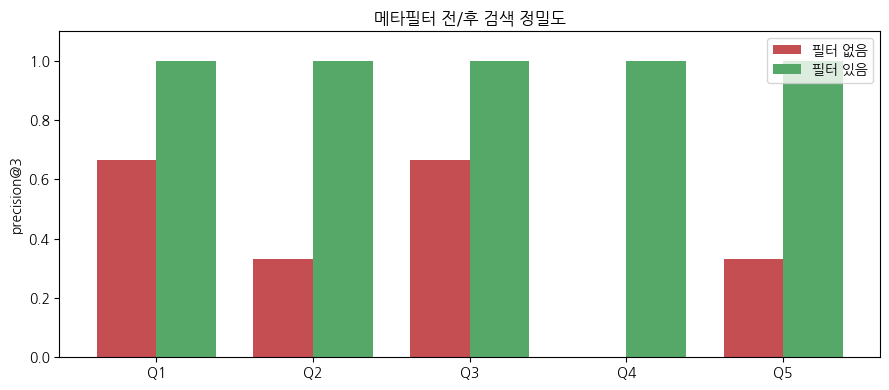

In [11]:
import matplotlib.pyplot as plt

no_each  = [precision_at_k(p, False) for p in PROBES]
yes_each = [precision_at_k(p, True)  for p in PROBES]
import numpy as np
x = np.arange(len(PROBES)); w = 0.38
plt.figure(figsize=(9, 4))
plt.bar(x - w/2, no_each,  w, label="필터 없음", color="#C44E52")
plt.bar(x + w/2, yes_each, w, label="필터 있음", color="#55A868")
plt.xticks(x, [f"Q{i+1}" for i in range(len(PROBES))]); plt.ylim(0, 1.1)
plt.ylabel("precision@3"); plt.title("메타필터 전/후 검색 정밀도")
plt.legend(); plt.tight_layout(); plt.show()

> 해석: 의미는 비슷하나 연도/회사가 다른 오답이 필터로 제거되어 정밀도가 오름

## Self-Query 일괄 정확도
- Self-Query가 여러 질문에서 회사·연도 필터를 **정확히** 뽑는지 일괄 평가 (사람이 손으로 안 짜도 되는지 확인)

### Self-Query 정확도 일괄 채점
- 여러 질문에서 Claude가 회사·연도 필터를 **정확히** 뽑는지 한 번에 점검
- `OK`가 많을수록 사람이 손댈 필요가 적다는 뜻


In [12]:
# 예상 호출: PROBES 건수만큼 Self-Query (소규모)
sq_correct = 0
for p in PROBES:
    f = self_query(p["q"])
    ok = (f.get("company") == p["company"]) and (f.get("year") == p["year"])
    sq_correct += ok
    print(p["q"].ljust(28),
          "추출:", {"company": f.get("company"), "year": f.get("year")}, "->", "OK" if ok else "MISS")
print(f"\nSelf-Query 정확도: {sq_correct}/{len(PROBES)}")

2023년 노바테크 매출                추출: {'company': '노바테크', 'year': 2023} -> OK
2022년 그린모빌리티 실적              추출: {'company': '그린모빌리티', 'year': 2022} -> OK
2023년 퀀텀칩 매출                 추출: {'company': '퀀텀칩', 'year': 2023} -> OK
2024년 노바테크 가이던스              추출: {'company': '노바테크', 'year': 2024} -> OK
오션로지스틱스 2023 매출              추출: {'company': '오션로지스틱스', 'year': 2023} -> OK

Self-Query 정확도: 5/5


## Contextual Retrieval (청크에 '문맥 한 줄' 붙이기)

### 개념 복습 · 청크가 문맥을 잃으면 검색이 실패한다
- 긴 문서를 잘게 쪼개면(청킹) 각 조각은 **자기가 무슨 문서의 어디였는지**를 잊어버림
- 예를 들어 `"매출은 1조 2천억 원이었다."` 라는 조각만 보면 — **어느 회사? 몇 년도?** 알 수가 없음
- 이러면 "2023년 노바테크 매출" 같은 질문이 와도 임베딩이 엉뚱한 조각을 가져올 수 있음
- **Contextual Retrieval**(Anthropic, 2024)은 간단한 처방: 청크를 임베딩하기 **전에**, Claude로 "이 조각이 어느 문서의 무엇인지" 한두 줄 **문맥 설명을 생성해 조각 앞에 붙인다(prepend)**
- 그러면 `"[노바테크의 2023년 재무 보고] 매출은 1조 2천억 원이었다."` 처럼 **스스로 설명되는 청크**가 되어 검색 적중률이 오름

> 쉽게 말하면 사진 한 장에 "누가·언제·어디서"를 적은 **포스트잇**을 붙여두는 것. 나중에 찾기 훨씬 쉬워짐

**용어**: *prepend* = 앞에 덧붙이기 · 문맥 요약(context) = 그 청크가 속한 문서/주제를 한 줄로 설명한 문장


### '문맥을 잃은' 짧은 청크 만들기
- 일부러 **회사·연도가 빠진 모호한 조각**들을 준비 (실제 청킹에서 흔히 생기는 상황을 합성으로 재현 — 실제 데이터 아님)
- 이 조각들은 그대로 임베딩하면 검색이 잘 안 될 후보들
- 다음 셀에서 Claude가 문맥을 채워줄 거임


In [13]:
# 문맥이 빠진 '모호한' 청크(합성). 원문서(부모)는 알지만 조각만 보면 회사/연도가 불명확하다.
AMBIG_CHUNKS = [
    {"id": "c0", "parent": "노바테크 2023 연차보고서", "text": "매출은 1조 2천억 원, 영업이익은 1,800억 원을 기록했다."},
    {"id": "c1", "parent": "그린모빌리티 2023 사업보고서", "text": "친환경 선박용 배터리 비중이 늘며 매출 8천억 원을 달성했다."},
    {"id": "c2", "parent": "퀀텀칩 2023 IR 자료", "text": "데이터센터용 신규 칩을 출시하고 매출 9천억 원을 올렸다."},
    {"id": "c3", "parent": "노바테크 2022 연차보고서", "text": "매출은 9천억 원으로 전년 대비 성장했다."},
    {"id": "c4", "parent": "오션로지스틱스 2023 사업보고서", "text": "매출 3천억 원, 친환경 선박 비중을 확대했다."},
]
print(len(AMBIG_CHUNKS), "개의 모호한 청크 준비")
for c in AMBIG_CHUNKS[:2]:
    print(" 조각만 보면:", c["text"], "  ← 어느 회사? 몇 년도?")


5 개의 모호한 청크 준비
 조각만 보면: 매출은 1조 2천억 원, 영업이익은 1,800억 원을 기록했다.   ← 어느 회사? 몇 년도?
 조각만 보면: 친환경 선박용 배터리 비중이 늘며 매출 8천억 원을 달성했다.   ← 어느 회사? 몇 년도?


### Claude로 청크별 '문맥 한 줄' 생성 → 앞에 붙이기
- 각 조각에 대해, **부모 문서가 무엇인지** 알려주고 Claude에게 "이 조각이 어느 회사·어느 시기·어떤 내용인지" 한 줄 요약을 만들게 함
- 그 요약을 조각 앞에 붙여 **문맥이 들어간 청크**를 만듦
- **출력 읽는 법**: `원본` vs `문맥주입` 두 버전을 나란히 보여줌
- 문맥주입본은 회사·연도가 앞에 명시됨


In [14]:
# Claude로 청크별 문맥 요약 생성 → 원청크 앞에 prepend. (생성 = Claude, anthropic SDK)
# 예상 호출: len(AMBIG_CHUNKS)건 (소규모). 정확도가 더 필요하면 MODEL="claude-opus-4-8"로 상향 가능.
def make_context(parent_title, chunk_text):
    """이 청크가 속한 문서를 알려주고, 검색에 도움 될 한 줄 문맥을 만들게 한다."""
    prompt = (f"전체 문서: '{parent_title}'\n"
              f"이 문서의 한 조각: \"{chunk_text}\"\n\n"
              "이 조각이 검색에서 잘 찾아지도록, 어느 회사·어느 연도·무슨 내용인지를 "
              "20자 내외 한 줄로만 답하라(설명 문장 없이 핵심만).")
    return ask_claude(prompt, max_tokens=80).strip().splitlines()[0]

contextualized = []
for c in AMBIG_CHUNKS:
    ctx = make_context(c["parent"], c["text"])
    enriched = f"[{ctx}] {c['text']}"   # 문맥을 청크 앞에 prepend
    contextualized.append({**c, "context": ctx, "enriched": enriched})

print("=== 원본 vs 문맥주입 ===")
for c in contextualized[:3]:
    print("원본    :", c["text"])
    print("문맥주입:", c["enriched"], "\n")


=== 원본 vs 문맥주입 ===
원본    : 매출은 1조 2천억 원, 영업이익은 1,800억 원을 기록했다.
문맥주입: [노바테크 2023년 매출 1.2조·영업이익 1,800억] 매출은 1조 2천억 원, 영업이익은 1,800억 원을 기록했다. 

원본    : 친환경 선박용 배터리 비중이 늘며 매출 8천억 원을 달성했다.
문맥주입: [**그린모빌리티 2023년 친환경 선박용 배터리 매출 8천억 원 달성**] 친환경 선박용 배터리 비중이 늘며 매출 8천억 원을 달성했다. 

원본    : 데이터센터용 신규 칩을 출시하고 매출 9천억 원을 올렸다.
문맥주입: [퀀텀칩 2023년 데이터센터 칩 출시·매출 9천억] 데이터센터용 신규 칩을 출시하고 매출 9천억 원을 올렸다. 



### 문맥주입 전/후 '검색 실패율' 비교
- 같은 질문들을 **(A) 원본 청크 인덱스**와 **(B) 문맥주입 청크 인덱스**에 각각 던져, top-1이 정답 조각인지 봄
- 정답을 top-1으로 못 가져오면 '검색 실패'로 셈
- **문맥주입 쪽 실패율이 낮으면** Contextual Retrieval이 효과 있는 것
- **출력 읽는 법**: `검색 실패율(원본)` vs `검색 실패율(문맥주입)` — 뒤가 더 낮을수록 좋음


In [15]:
# 두 개의 별도 인덱스(원본 / 문맥주입)를 만들어 동일 질문셋으로 검색 실패율을 비교한다.
# chromadb 컬렉션 2개 사용(임베딩=sentence-transformers, 비-Claude 검색 인프라).
raw_col = chroma.get_or_create_collection("ctx_raw", embedding_function=ef)
enr_col = chroma.get_or_create_collection("ctx_enriched", embedding_function=ef)
# 이미 들어있을 수 있으니(재실행) 초기화 위해 새 이름이면 그대로, 중복 add 방지로 안전하게 재생성
for name, coll, key in [("ctx_raw", raw_col, "text"), ("ctx_enriched", enr_col, "enriched")]:
    try:
        chroma.delete_collection(name)
    except Exception:
        pass
raw_col = chroma.get_or_create_collection("ctx_raw", embedding_function=ef)
enr_col = chroma.get_or_create_collection("ctx_enriched", embedding_function=ef)
raw_col.add(ids=[c["id"] for c in contextualized],
            documents=[c["text"] for c in contextualized])
enr_col.add(ids=[c["id"] for c in contextualized],
            documents=[c["enriched"] for c in contextualized])

# 질문 → 정답 조각 id (회사·연도가 정확히 매칭되는 조각)
CTX_PROBES = [
    {"q": "2023년 노바테크 매출과 영업이익", "gold": "c0"},
    {"q": "2023년 그린모빌리티 매출",        "gold": "c1"},
    {"q": "2023년 퀀텀칩 매출",              "gold": "c2"},
    {"q": "2022년 노바테크 매출",            "gold": "c3"},
    {"q": "2023년 오션로지스틱스 매출",      "gold": "c4"},
]
def fail_rate(coll):
    fails = 0
    for pr in CTX_PROBES:
        top1 = coll.query(query_texts=[pr["q"]], n_results=1)["ids"][0][0]
        if top1 != pr["gold"]:
            fails += 1
    return fails / len(CTX_PROBES)

fail_raw = fail_rate(raw_col)
fail_enr = fail_rate(enr_col)
print(f"검색 실패율(원본 청크)     : {fail_raw:.2f}")
print(f"검색 실패율(문맥주입 청크) : {fail_enr:.2f}")

검색 실패율(원본 청크)     : 0.80
검색 실패율(문맥주입 청크) : 0.40


> → 문맥을 prepend하면 모호한 조각도 '어느 회사·연도'가 드러나 top-1 적중이 오름

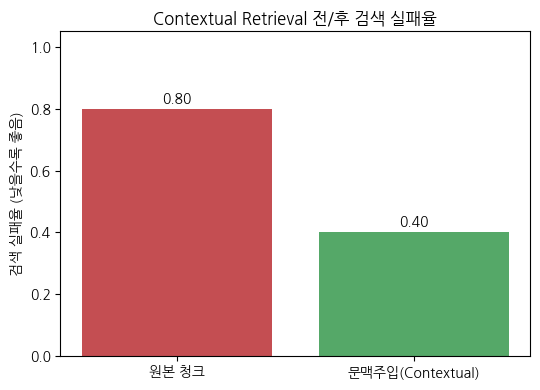

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5.5, 4))
bars = plt.bar(["원본 청크", "문맥주입(Contextual)"], [fail_raw, fail_enr],
               color=["#C44E52", "#55A868"])
plt.ylim(0, 1.05); plt.ylabel("검색 실패율 (낮을수록 좋음)")
plt.title("Contextual Retrieval 전/후 검색 실패율")
for b, v in zip(bars, [fail_raw, fail_enr]):
    plt.text(b.get_x()+b.get_width()/2, v+0.02, f"{v:.2f}", ha="center")
plt.tight_layout(); plt.show()

> 해석: 막대가 낮을수록 검색이 잘 된 것. 문맥주입 막대가 더 낮으면 효과 입증

### 비용 노트 · prompt caching과 결합하기
- 문서가 수천 개면 청크마다 Claude를 부르는 비용이 부담됨
- **prompt caching**을 쓰면 같은 부모 문서를 반복해서 읽힐 때, "안 바뀌는 앞부분(전체 문서)"을 캐시해 두 번째부터 거의 공짜로 처리 (캐시 읽기 ~0.1x, 최대 90%↓)

```python
# 같은 부모 문서의 여러 청크에 문맥을 만들 때: 문서 전문을 캐시 → 청크만 바꿔 반복 호출
resp = client.messages.create(
    model="claude-sonnet-4-6",
    system=[
        {"type": "text", "text": "청크에 검색용 문맥 한 줄을 붙이는 도우미."},
        {"type": "text", "text": FULL_DOCUMENT,           # 부모 문서 전문(안 바뀜)
         "cache_control": {"type": "ephemeral"}},          # ← 여기에 캐시를 건다
    ],
    messages=[{"role": "user", "content": f"이 조각의 문맥 한 줄: {chunk}"}],
    max_tokens=80,
)
# 핵심: prefix-match라 '바뀌지 않는 앞부분'(문서 전문)을 앞에 두고 cache_control을 건다.
```
> 쉽게 말하면 같은 자료를 계속 다시 읽히면 돈이 든다 → 안 바뀌는 앞부분을 '캐시'해 두면 두 번째부터 거의 공짜  
> Anthropic은 Contextual Retrieval + contextual BM25(키워드) + prompt caching을 함께 쓰면 검색 실패가 크게 준다고 보고


### 직접 해보기: 문맥 요약을 더 풍부하게
- 문맥 한 줄에 **업종/사업 키워드**까지 넣으면 의미형 질문("배터리 만드는 회사의 2023년 실적")에도 강해질까?


In [17]:
# 직접 해보기: make_context 프롬프트를 바꿔 '업종/키워드'까지 넣은 문맥을 만들어 비교해 보세요.
# 힌트: 아래 함수의 지시문 한 줄만 바꿔 enriched2 인덱스를 만들고 fail_rate로 비교합니다.
def make_context_rich(parent_title, chunk_text):
    prompt = (f"전체 문서: '{parent_title}'\n조각: \"{chunk_text}\"\n\n"
              # 힌트: 아래 지시문에 '업종/핵심 사업 키워드도 포함'을 추가해 보세요.
              "회사·연도·핵심 내용에 더해 업종/사업 키워드까지 25자 내외 한 줄로 답하라.")
    return ask_claude(prompt, max_tokens=90).strip().splitlines()[0]

# (예시) 첫 청크만 비교 출력
demo = make_context_rich(AMBIG_CHUNKS[0]["parent"], AMBIG_CHUNKS[0]["text"])
print("기존 문맥 :", contextualized[0]["context"])
print("풍부 문맥 :", demo)
print("→ 업종 키워드가 들어가면 '배터리/칩 만드는 회사' 같은 의미형 질문에 더 잘 잡힌다.")

기존 문맥 : 노바테크 2023년 매출 1.2조·영업이익 1,800억
풍부 문맥 : **노바테크 2023년 연차보고서 — 매출 1.2조·영업이익 1,800억 달성**
→ 업종 키워드가 들어가면 '배터리/칩 만드는 회사' 같은 의미형 질문에 더 잘 잡힌다.


## 표 → Text2SQL 맛보기 (sqlite)
- 표는 의미검색보다 **구조화 질의**(SQL)가 정확
- 재무표를 sqlite에 적재하고 Claude가 자연어→SQL을 생성하게 함 (sqlite=표준 라이브러리, 비-LLM 인프라. SQL 생성만 Claude)

### 표는 SQL로 묻기(Text2SQL)
- 숫자 표는 의미검색보다 **데이터베이스 조회(SQL)**가 정확
- 재무표를 임시 DB(sqlite)에 넣고, Claude가 자연어 질문을 **SQL로 변환**하게 함
- **출력 읽는 법**: '생성 SQL'에 `SELECT ...`가 나오고 '결과'에 올바른 회사가 나오면 성공


In [18]:
# 정확도가 더 필요하면 이 judge/추출 셀의 모델을 MODEL_JUDGE = "claude-opus-4-8" 로 한 줄 상향 가능(기본은 비용 위해 sonnet 4.6).
import sqlite3
conn = sqlite3.connect(":memory:")
cur = conn.cursor()
cur.execute("CREATE TABLE financials (company TEXT, year INT, revenue INT, op_income INT)")
for row in TABLE["rows"]:
    cur.execute("INSERT INTO financials VALUES (?,?,?,?)", row)
conn.commit()

SQL_TOOL = [{
  "name": "run_sql",
  "description": "financials(company TEXT, year INT, revenue INT, op_income INT) 테이블을 조회하는 SQLite SELECT 문 생성",
  "input_schema": {"type": "object",
    "properties": {"sql": {"type": "string", "description": "SELECT 문만"}},
    "required": ["sql"]}
}]

def text2sql(question):
    msg = client.messages.create(model=MODEL, max_tokens=300, tools=SQL_TOOL,
        tool_choice={"type": "tool", "name": "run_sql"},
        messages=[{"role": "user", "content":
            f"테이블 financials(company, year, revenue, op_income). 질문: {question}"}])
    for b in msg.content:
        if b.type == "tool_use": return b.input["sql"]

q = "영업이익이 가장 높은 회사는?"
sql = text2sql(q)
print("생성 SQL:", sql)
try:
    cur.execute(sql); print("결과:", cur.fetchall())
except Exception as e:
    print("SQL 실행 오류(프롬프트/스키마 점검):", e)

생성 SQL: SELECT company, MAX(op_income) AS max_op_income FROM financials
결과: [('노바테크', 1800)]


## 직접 해보기: Text2SQL 집계 질의
- "2023년 전체 회사 매출 합계는?" 같은 집계 질문을 던져 Claude가 `SUM`을 쓰는지 관찰하기

In [19]:
# 직접 해보기: 합계/정렬이 필요한 질문도 Claude가 SQL로 잘 만들까요?
# 힌트: 주석을 풀고 질문만 바꿔보세요. SUM, ORDER BY 같은 게 SQL에 나오는지 관찰합니다.
my_q = "2023년 매출 상위 2개 회사는?"
sql = text2sql(my_q)
print("생성 SQL:", sql)
try:
    cur.execute(sql); print('결과:', cur.fetchall())
except Exception as e:
    print('SQL 실행 오류:', e)


생성 SQL: SELECT company, revenue FROM financials WHERE year = 2023 ORDER BY revenue DESC LIMIT 2
결과: [('노바테크', 12000), ('퀀텀칩', 9000)]


## 검증: 메타필터 효과 + Text2SQL

### 심화 부분 종합 검증
- 필터가 정밀도를 해치지 않는지, Self-Query가 과반 이상 맞는지, Text2SQL이 SELECT를 만드는지 자동 확인
- `통과`면 정상


In [20]:
# 1) 필터가 평균 정밀도를 떨어뜨리지 않아야 한다(보통 향상)
assert p_yes >= p_no - 1e-9, "메타필터가 정밀도를 악화시켜선 안 됨"
# 2) Self-Query가 최소 과반은 맞혀야 한다
assert sq_correct >= len(PROBES) // 2, "Self-Query 정확도가 과반 미만"
# 3) Text2SQL이 SELECT 문을 생성해야 한다
assert sql and "select" in sql.lower(), "Text2SQL이 SELECT를 생성하지 못함"
# 4) Contextual Retrieval: 문맥주입이 검색 실패율을 악화시키지 않아야 한다(보통 개선)
assert fail_enr <= fail_raw + 1e-9, "문맥주입(Contextual)이 검색 실패율을 악화시켜선 안 됨"
print("심화 검증 통과")

심화 검증 통과


## 확장과제
- **Text2SQL 고도화**: JOIN이 필요한 다중 테이블(예: 회사-임원)을 추가하고 Claude가 JOIN을 생성하는지 보기
- **메타 스키마 확장**: 분기(quarter)를 추가하고 Self-Query가 추출하도록 tool 스키마를 늘림
- **하이브리드 라우팅**: 질문이 "수치/집계"면 Text2SQL, "서술/근거"면 벡터검색으로 보내는 라우터를 설계
- 메타필터 + Self-Query 결과를 lab3 Hybrid 검색의 사전 필터로 결합해 보기